# Demo: Training the Lake Drainage Classifier

This notebook demonstrates how to train the LakeDrainageClassifier on processed lake data.

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from lakevision.data.datasets import LakeDataset
from lakevision.models.classifier import LakeDrainageClassifier

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Working directory: {Path.cwd()}")

Using device: cpu
Working directory: /Users/jrines/stanford_gp/research/lakes/2026/lake-vision


## Load data

In [5]:
# Paths to data and labels
PROCESSED_DATA_PATH = Path("datasets/processed/CW2019_1579.nc")
LABELS_PATH = Path("labels/labels_2019_volumes_CW_demo.csv")

print(f"Data exists: {PROCESSED_DATA_PATH.exists()}")
print(f"Labels exist: {LABELS_PATH.exists()}")

# Create dataset
dataset = LakeDataset(
    PROCESSED_DATA_PATH,
    seq_len=21,
    labels_file=LABELS_PATH,
    id_col='new_id',
    label_col='label_rines'
)

# Create dataloader
loader = DataLoader(dataset, batch_size=1, shuffle=False)

# Inspect one sample
img_seq, area_seq, label, lake_id = dataset[0]
print(f"\nDataset size: {len(dataset)}")
print(f"Lake ID: {lake_id}")
print(f"Label: {label.item()}")
print(f"Image sequence shape: {img_seq.shape}")
print(f"Area sequence shape: {area_seq.shape}")

Data exists: True
Labels exist: True

Dataset size: 1
Lake ID: CW2019_1579
Label: 1
Image sequence shape: torch.Size([21, 4, 512, 512])
Area sequence shape: torch.Size([21, 1])


In [6]:
# Initialize model
model = LakeDrainageClassifier(
    use_imgseq=True,
    use_areaseq=True,
    use_cloudyseq=False,
    attention_type='spatial',
)
model = model.to(device)

print(model)

LakeDrainageClassifier(
  Features: imgseq=True, areaseq=True, cloudyseq=False
  Attention: spatial
  Feature dims: {'img_features': 32, 'area_features': 16, 'total': 48}
  Total parameters: 139,958
)


In [12]:
# Training configuration
NUM_EPOCHS = 200
LEARNING_RATE = 1e-4

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Storage for metrics
history = {
    'epoch': [],
    'loss': [],
    'accuracy': [],
    'predicted': [],
    'logits': []
}

In [13]:
# Training loop
model.train()

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    correct = 0
    total = 0
    
    for img_seq, area_seq, label, lake_id in loader:
        # Move to device
        img_seq = img_seq.to(device)
        area_seq = area_seq.to(device)
        label = label.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        logits = model(img_seq, area_seq, None)
        loss = criterion(logits, label)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track metrics
        epoch_loss += loss.item()
        pred = logits.argmax(dim=1)
        correct += (pred == label).sum().item()
        total += label.size(0)
    
    # Store history
    avg_loss = epoch_loss / len(loader)
    accuracy = correct / total
    
    history['epoch'].append(epoch + 1)
    history['loss'].append(avg_loss)
    history['accuracy'].append(accuracy)
    history['predicted'].append(pred.item())
    history['logits'].append(logits.detach().cpu().numpy().flatten())
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy().flatten()
        print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f} | Pred: {pred.item()} | True: {label.item()} | Probs: {np.round(probs, 3)}")

print("\nTraining complete!")

Epoch   1 | Loss: 1.1199 | Pred: 1 | True: 1 | Probs: [0.267 0.326 0.208 0.199]
Epoch  10 | Loss: 1.0304 | Pred: 1 | True: 1 | Probs: [0.265 0.357 0.187 0.191]
Epoch  20 | Loss: 0.9128 | Pred: 1 | True: 1 | Probs: [0.261 0.401 0.164 0.173]
Epoch  30 | Loss: 0.8031 | Pred: 1 | True: 1 | Probs: [0.244 0.448 0.147 0.161]
Epoch  40 | Loss: 0.7438 | Pred: 1 | True: 1 | Probs: [0.232 0.475 0.137 0.156]
Epoch  50 | Loss: 0.6877 | Pred: 1 | True: 1 | Probs: [0.213 0.503 0.13  0.154]
Epoch  60 | Loss: 0.6410 | Pred: 1 | True: 1 | Probs: [0.203 0.527 0.122 0.148]
Epoch  70 | Loss: 0.5805 | Pred: 1 | True: 1 | Probs: [0.187 0.56  0.112 0.142]
Epoch  80 | Loss: 0.5331 | Pred: 1 | True: 1 | Probs: [0.176 0.587 0.104 0.134]
Epoch  90 | Loss: 0.4747 | Pred: 1 | True: 1 | Probs: [0.163 0.622 0.093 0.122]
Epoch 100 | Loss: 0.4333 | Pred: 1 | True: 1 | Probs: [0.153 0.648 0.085 0.114]
Epoch 110 | Loss: 0.3983 | Pred: 1 | True: 1 | Probs: [0.144 0.671 0.078 0.106]
Epoch 120 | Loss: 0.3658 | Pred: 1 | Tru

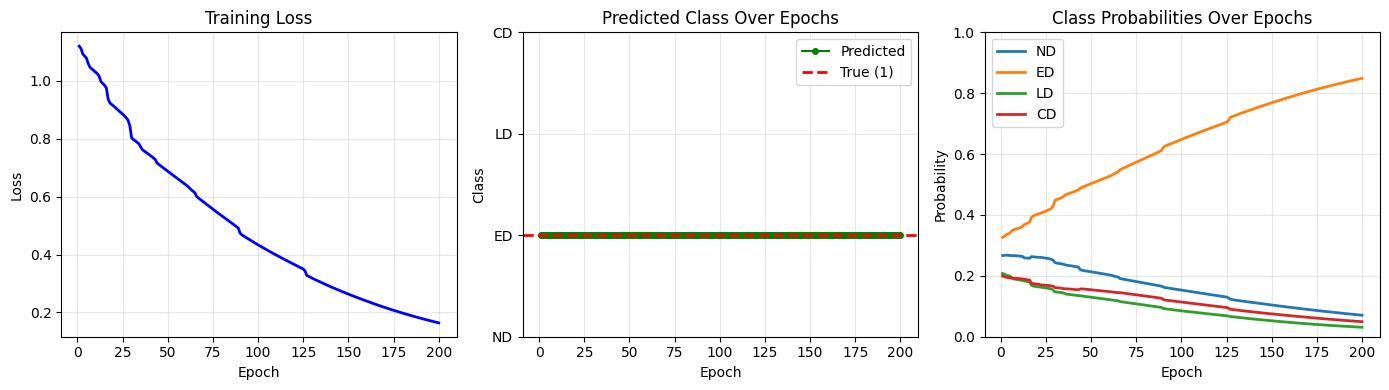

In [14]:
# Plot training results
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Loss curve
axes[0].plot(history['epoch'], history['loss'], 'b-', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

# Prediction over time
axes[1].plot(history['epoch'], history['predicted'], 'go-', markersize=4, label='Predicted')
axes[1].axhline(y=label.item(), color='r', linestyle='--', linewidth=2, label=f'True ({label.item()})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Class')
axes[1].set_title('Predicted Class Over Epochs')
axes[1].set_yticks([0, 1, 2, 3])
axes[1].set_yticklabels(['ND', 'ED', 'LD', 'CD'])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Class probabilities over time
logits_array = np.array(history['logits'])
probs_array = np.exp(logits_array) / np.exp(logits_array).sum(axis=1, keepdims=True)  # softmax

for i, cls_name in enumerate(['ND', 'ED', 'LD', 'CD']):
    axes[2].plot(history['epoch'], probs_array[:, i], label=cls_name, linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Probability')
axes[2].set_title('Class Probabilities Over Epochs')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [15]:
# Final evaluation
model.eval()
with torch.no_grad():
    img_seq, area_seq, label, lake_id = dataset[0]
    img_seq = img_seq.unsqueeze(0).to(device)
    area_seq = area_seq.unsqueeze(0).to(device)
    
    logits = model(img_seq, area_seq, None)
    probs = torch.softmax(logits, dim=1).cpu().numpy().flatten()
    pred = logits.argmax(dim=1).item()

class_names = ['ND (No Drainage)', 'ED (Englacial)', 'LD (Lateral)', 'CD (Crevasse)']

print(f"Lake: {lake_id}")
print(f"True label: {label.item()} ({class_names[label.item()]})")
print(f"Predicted:  {pred} ({class_names[pred]})")
print(f"\nClass probabilities:")
for i, (name, prob) in enumerate(zip(class_names, probs)):
    marker = " <--" if i == label.item() else ""
    print(f"  {name}: {prob:.4f}{marker}")


Lake: CW2019_1579
True label: 1 (ED (Englacial))
Predicted:  1 (ED (Englacial))

Class probabilities:
  ND (No Drainage): 0.0701
  ED (Englacial): 0.8502 <--
  LD (Lateral): 0.0307
  CD (Crevasse): 0.0490


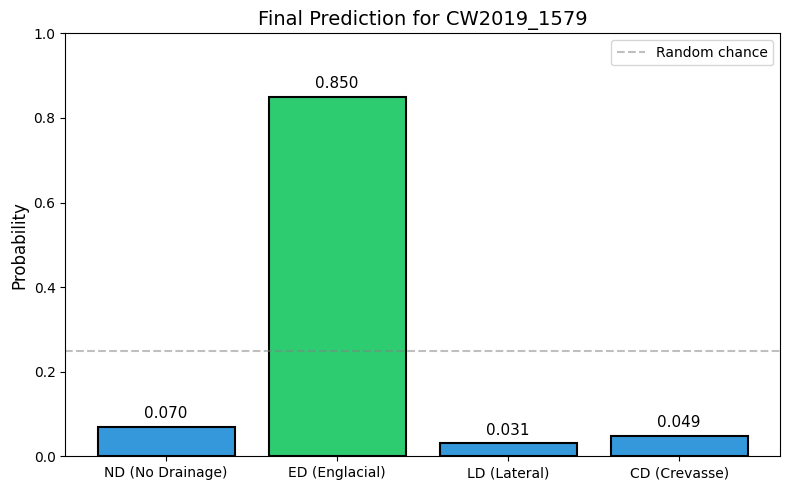

In [16]:
# Visualize final probabilities
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2ecc71' if i == label.item() else '#3498db' for i in range(4)]
bars = ax.bar(class_names, probs, color=colors, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Probability', fontsize=12)
ax.set_title(f'Final Prediction for {lake_id}', fontsize=14)
ax.set_ylim(0, 1)
ax.axhline(y=0.25, color='gray', linestyle='--', alpha=0.5, label='Random chance')

# Add value labels on bars
for bar, prob in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{prob:.3f}', ha='center', fontsize=11)

ax.legend()
plt.tight_layout()
plt.show()
